# 02 · Rainfall, soil moisture and river discharge

Downloads the daily model inputs from Open-Meteo for the study districts, using the same providers the WeatherGPT backend already calls.

**Scope.** Open-Meteo's free tier charges by data volume, not by request: anything over two weeks for one location counts as several calls, and the ceilings are 5,000 an hour and 10,000 a day. Forty years for all 75 districts would cost roughly 240,000 units, so the study covers **14 districts over 2004-2023, monsoon season only (1 May to 31 Oct)**: about 1,100 units to locate the rivers and 7,400 to download, roughly 8,400 in total against a 10,000 daily ceiling. May is included so that June onsets have 30 days of antecedent rainfall behind them.

**Input:** notebook 01's output. Attach it through **Add Input → Notebooks**.

**Sources:** ERA5-Land (rainfall, soil moisture) and GloFAS v4 river discharge, both via Open-Meteo, CC BY 4.0. The paper must credit Open-Meteo, ECMWF/Copernicus and the Copernicus Emergency Management Service.

**Output:** `up_daily_features.parquet`, `up_river_points.csv`, `study_districts.csv`, `fig_seasonality.png`.


In [21]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

WORK = Path("/kaggle/working")
OUT = WORK / "outputs"
CACHE = WORK / "cache"
OUT.mkdir(exist_ok=True)
CACHE.mkdir(exist_ok=True)

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
FLOOD_URL = "https://flood-api.open-meteo.com/v1/flood"
MODEL = "era5"
TZ = "Asia/Kolkata"

FIRST_YEAR = 2004
LAST_YEAR = 2023
SEASON = ("05-01", "10-31")
PER_GROUP = 7
LON_SPLIT = 81.0
PROBE = ("2019-08-05", "2019-08-18")
MIN_DISCHARGE = 500

HOURLY_BUDGET = 4000
RUN_BUDGET = 9200
BATCH = 25

spent = 0.0

In [22]:
inputs = next(p.parent for p in Path("/kaggle/input").rglob("up_flood_labels.csv"))
labels = pd.read_csv(inputs / "up_flood_labels.csv", parse_dates=["start"])
points = pd.read_csv(inputs / "up_district_points.csv")
candidates = pd.read_csv(inputs / "up_river_candidates.csv")
print(inputs)

/kaggle/input/notebooks/rudranshiverma/01-flood-labels-and-district-point/outputs


## Choose the study districts

Two groups either side of 81°E: the eastern Ghaghara-Rapti belt, and the central Ganga-Gomti belt. Within each group the notebook keeps the 7 districts with the most recorded floods, since rare-event models need positives to learn from.


In [23]:
season_labels = labels[labels["start"].dt.year.between(FIRST_YEAR, LAST_YEAR) & labels["start"].dt.month.between(6, 10)]
onsets = season_labels.groupby("district").size().rename("onsets").reset_index()
ranked = points.merge(onsets, on="district", how="left").fillna({"onsets": 0})
ranked["group"] = ranked["lon"].map(lambda lon: "east" if lon >= LON_SPLIT else "central")

selected = ranked.sort_values("onsets", ascending=False).groupby("group").head(PER_GROUP)
selected = selected.sort_values(["group", "onsets"], ascending=[True, False]).reset_index(drop=True)
print(selected[["district", "group", "onsets"]].to_string(index=False))
print(f"\n{int(selected['onsets'].sum())} flood onsets across {len(selected)} districts")

    district   group  onsets
     sitapur central      35
kanpur dehat central      20
    fatehpur central      18
       kheri central      18
kanpur nagar central      13
       unnao central      13
      etawah central      13
       gonda    east      27
  bara banki    east      26
    bahraich    east      24
      ballia    east      18
    faizabad    east      15
   prayagraj    east      15
  pratapgarh    east      14

269 flood onsets across 14 districts


## Budget and fetching

`units` mirrors Open-Meteo's counting rule of one call per 14 days per location. `spend` stops the run before the daily ceiling rather than after, and `wait_for` paces requests under the hourly ceiling. A 429 pauses for ten minutes and retries, because the hourly allowance refills.

In [25]:
def units(days, locations=1):
    return locations * max(1.0, days / 14)


def wait_for(cost):
    time.sleep(3600 * cost / HOURLY_BUDGET)


def spend(cost):
    global spent
    if spent + cost > RUN_BUDGET:
        raise RuntimeError(f"run budget reached ({spent:.0f} units). Cached districts are kept - rerun later to continue.")
    spent += cost


def fetch(url, params, cost, tries=6):
    spend(cost)
    for attempt in range(tries):
        try:
            response = requests.get(url, params=params, timeout=180)
        except requests.exceptions.RequestException as error:
            print(f"network error ({error.__class__.__name__}), retrying", flush=True)
            time.sleep(30 * (attempt + 1))
            continue
        if response.status_code == 429:
            print("rate limited, waiting 10 min", flush=True)
            time.sleep(600)
            continue
        if response.status_code >= 500:
            time.sleep(15 * (attempt + 1))
            continue
        response.raise_for_status()
        return response.json()
    raise RuntimeError(f"{url} kept failing after {tries} attempts")

## Pick each district's river

Discharge snaps to the nearest modelled river, so the coordinate matters at 5 km resolution. Candidates come from notebook 01's grid, which extends about 11 km past each district boundary because many UP districts have their main river on the edge rather than in the middle. Each district keeps its highest-flow candidate.

The probe window is exactly 14 days in peak monsoon, which is Open-Meteo's minimum billing unit: one call per location regardless. Ranking candidates needs relative flow, not a long record, so a fortnight is enough and 1,160 points cost about 1,160 units. The result is cached, so this is paid for once.

In [27]:
probe_days = len(pd.date_range(*PROBE))
probe_points = candidates[candidates["district"].isin(selected["district"])].reset_index(drop=True)
print(f"{len(probe_points)} candidates, about {units(probe_days, len(probe_points)):.0f} units")

probe_file = CACHE / "river_probe_buffered.csv"
if probe_file.exists():
    probe_points = pd.read_csv(probe_file)
else:
    means = []
    for start in range(0, len(probe_points), BATCH):
        batch = probe_points.iloc[start : start + BATCH]
        cost = units(probe_days, len(batch))
        payload = fetch(
            FLOOD_URL,
            {
                "latitude": ",".join(str(v) for v in batch["lat"]),
                "longitude": ",".join(str(v) for v in batch["lon"]),
                "daily": "river_discharge",
                "start_date": PROBE[0],
                "end_date": PROBE[1],
            },
            cost,
        )
        payload = payload if isinstance(payload, list) else [payload]
        if len(payload) != len(batch):
            raise RuntimeError(f"asked for {len(batch)} locations, got {len(payload)}")
        means.extend(pd.Series(item["daily"]["river_discharge"], dtype="float64").mean() for item in payload)
        wait_for(cost)
    probe_points["mean_discharge"] = means
    probe_points.to_csv(probe_file, index=False)

rivers = probe_points.sort_values("mean_discharge", ascending=False).groupby("district", as_index=False).first()
rivers = rivers.sort_values("mean_discharge", ascending=False).reset_index(drop=True)
rivers["check"] = rivers["mean_discharge"] < MIN_DISCHARGE
print(rivers.to_string(index=False))
print()
print(
    f"{int(rivers['check'].sum())} districts below {MIN_DISCHARGE} m3/s - confirm each really has no major river before continuing"
)

1043 candidates, about 1043 units
    district  lat  lon  mean_discharge  check
      ballia 25.7 84.7    21385.870714  False
   prayagraj 25.3 82.0    10733.110714  False
    fatehpur 25.8 80.5     8033.309286  False
kanpur nagar 25.9 80.2     7374.157857  False
    faizabad 26.7 82.3     6843.656429  False
       gonda 26.8 82.0     6769.857143  False
  bara banki 26.9 81.7     6680.281429  False
    bahraich 27.0 81.5     6671.817857  False
     sitapur 27.3 81.4     6632.390714  False
       kheri 27.7 81.2     6280.768571  False
      etawah 26.4 79.2     6165.991429  False
kanpur dehat 26.3 79.5     6025.297143  False
  pratapgarh 25.5 81.6     2438.037857  False
       unnao 26.1 80.8     2365.171429  False

0 districts below 500 m3/s - confirm each really has no major river before continuing


In [18]:
print(len(rivers), rivers["mean_discharge"].min())

14 2365.1714285714284


In [29]:
def fetch_year(district, year, rain, river):
    start, end = f"{year}-{SEASON[0]}", f"{year}-{SEASON[1]}"
    days = len(pd.date_range(start, end))
    cost = units(days)

    weather = fetch(
        ARCHIVE_URL,
        {
            "latitude": rain.lat,
            "longitude": rain.lon,
            "start_date": start,
            "end_date": end,
            "daily": "precipitation_sum",
            "hourly": "soil_moisture_0_to_7cm",
            "models": MODEL,
            "timezone": TZ,
        },
        cost,
    )
    wait_for(cost)

    discharge = fetch(
        FLOOD_URL,
        {
            "latitude": river.lat,
            "longitude": river.lon,
            "start_date": start,
            "end_date": end,
            "daily": "river_discharge",
        },
        cost,
    )
    wait_for(cost)

    soil = pd.DataFrame(weather["hourly"])
    soil["date"] = pd.to_datetime(soil["time"]).dt.date
    soil = soil.groupby("date")["soil_moisture_0_to_7cm"].mean()

    daily = pd.DataFrame(
        {
            "date": pd.to_datetime(weather["daily"]["time"]),
            "precip_mm": weather["daily"]["precipitation_sum"],
        }
    )
    daily["soil_moisture"] = daily["date"].dt.date.map(soil)
    flow = pd.Series(discharge["daily"]["river_discharge"], index=pd.to_datetime(discharge["daily"]["time"]))
    daily["discharge"] = flow.reindex(daily["date"]).values
    daily.insert(0, "district", district)
    return daily

## Smoke test

One district-year before the full run. Gonda in 2008 was a major Ghaghara flood, so rainfall and discharge should both peak during the monsoon, and nothing should be missing.

{'district': 0, 'date': 0, 'precip_mm': 0, 'soil_moisture': 0, 'discharge': 0} | 26 units spent


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

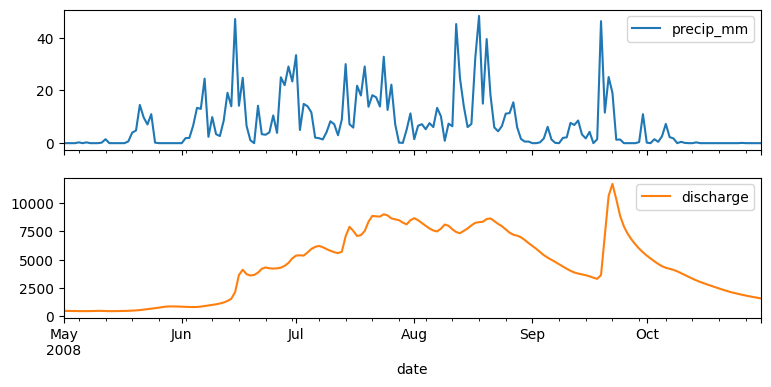

In [30]:
rain_by_district = selected.set_index("district")
river_by_district = rivers.set_index("district")

check = fetch_year("gonda", 2008, rain_by_district.loc["gonda"], river_by_district.loc["gonda"])
print(check.isna().sum().to_dict(), f"| {spent:.0f} units spent")
check.set_index("date")[["precip_mm", "discharge"]].plot(subplots=True, figsize=(9, 4))

## Download

Two calls per district-year. If the run stops on the budget guard or the connection drops, rerun this cell later and it continues from the cache.

In [31]:
def cache_path(district, year):
    return CACHE / f"{district.replace(' ', '_')}_{year}.parquet"


jobs = [
    (d, y) for d in rain_by_district.index for y in range(FIRST_YEAR, LAST_YEAR + 1) if not cache_path(d, y).exists()
]
print(f"{len(jobs)} district-years to fetch, about {units(184, len(jobs)) * 2:.0f} units")

for district, year in jobs:
    path = cache_path(district, year)
    daily = fetch_year(district, year, rain_by_district.loc[district], river_by_district.loc[district])
    daily.to_parquet(path, index=False)
    print(f"{district} {year} ({spent:.0f} units)", flush=True)

features = pd.concat(
    [pd.read_parquet(p) for p in sorted(CACHE.glob("*_[0-9][0-9][0-9][0-9].parquet"))], ignore_index=True
)
features = (
    features.merge(selected[["district", "group"]], on="district")
    .sort_values(["district", "date"])
    .reset_index(drop=True)
)
features.shape

0 district-years to fetch, about 0 units


(51520, 6)

In [ ]:
done = sorted(CACHE.glob("*_[0-9][0-9][0-9][0-9].parquet"))
print(len(done), "of 280 district-years")
print("newest:", max(done, key=lambda p: p.stat().st_mtime).name)
print("modified", (time.time() - max(p.stat().st_mtime for p in done)) / 60, "minutes ago")

## Checks

In [32]:
expected = len(selected) * sum(
    len(pd.date_range(f"{y}-{SEASON[0]}", f"{y}-{SEASON[1]}")) for y in range(FIRST_YEAR, LAST_YEAR + 1)
)
print(f"rows {len(features)} of {expected} expected, {features['district'].nunique()} districts")
print(f"missing: {features[['precip_mm', 'soil_moisture', 'discharge']].isna().mean().round(4).to_dict()}")
features[["precip_mm", "soil_moisture", "discharge"]].describe().round(3)

rows 51520 of 51520 expected, 14 districts
missing: {'precip_mm': 0.0, 'soil_moisture': 0.0, 'discharge': 0.0}


,precip_mm,soil_moisture,discharge
count,51520.000,51520.000,51520.000
mean,5.281,0.295,3678.475
std,11.210,0.105,4600.390
min,0.000,0.123,178.060
25%,0.000,0.176,662.740
50%,0.600,0.317,2031.360
75%,6.200,0.397,5259.170
max,220.800,0.439,41685.930


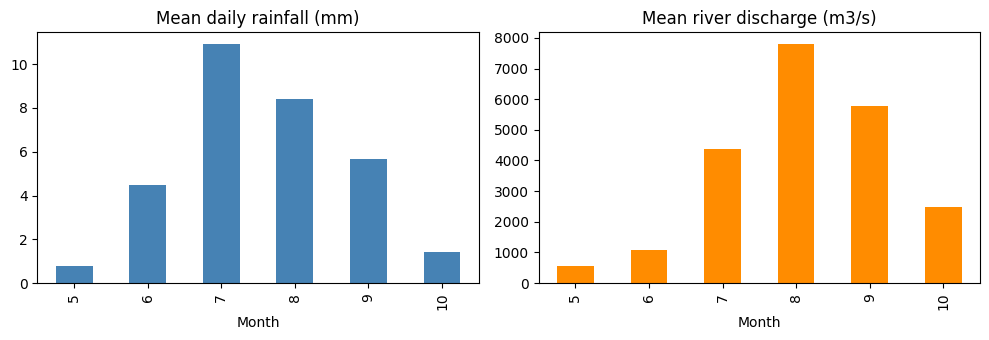

In [33]:
monthly = features.groupby(features["date"].dt.month)[["precip_mm", "discharge"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
monthly["precip_mm"].plot.bar(ax=axes[0], color="steelblue", title="Mean daily rainfall (mm)")
monthly["discharge"].plot.bar(ax=axes[1], color="darkorange", title="Mean river discharge (m3/s)")
for ax in axes:
    ax.set_xlabel("Month")
fig.tight_layout()
fig.savefig(OUT / "fig_seasonality.png", dpi=200)

Rainfall should peak in July-August and discharge in August-September, since rivers lag the rain feeding them. Discharge peaking first would mean the two series are misaligned.

In [34]:
features.to_parquet(OUT / "up_daily_features.parquet", index=False)
rivers.to_csv(OUT / "up_river_points.csv", index=False)
selected.to_csv(OUT / "study_districts.csv", index=False)
print(f"{spent:.0f} units spent in this run")
sorted(p.name for p in OUT.iterdir())

26 units spent in this run


['fig_seasonality.png',
 'study_districts.csv',
 'up_daily_features.parquet',
 'up_river_points.csv']